In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Load dataset
train_path = r'..\data\train.csv'
test_path = r'..\data\test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']



Train shape: (25010, 11)
Test shape: (1000000, 11)


In [5]:
#Initialize and train the MLPClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=2000, random_state=42))
])
accuracies = []
predictions = []

for i in range(5):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    predictions.append(y_pred)
    print(f"Trial {i+1} - Accuracy: {(acc*100):.2f}%")

print(f"Average accuracy: {(np.mean(accuracies)*100):.2f}%")

c:\Users\ADMIN\PokerHandPredict\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Trial 1 - Accuracy: 92.71%


c:\Users\ADMIN\PokerHandPredict\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Trial 2 - Accuracy: 92.71%


c:\Users\ADMIN\PokerHandPredict\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Trial 3 - Accuracy: 92.71%


c:\Users\ADMIN\PokerHandPredict\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Trial 4 - Accuracy: 92.71%


c:\Users\ADMIN\PokerHandPredict\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Trial 5 - Accuracy: 92.71%
Average accuracy: 92.71%


In [7]:
#Model Selection using Cross-Validation
param_grid = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64)], 
    'mlp__alpha': [0.0001, 0.001],                    
    'mlp__learning_rate_init': [0.001, 0.01]          
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

best_mlp = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters found:  {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.01}
Best cross-validation accuracy: 99.30%


Test accuracy with best MLP classifier: 99.65%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       0.98      0.99      0.99     47622
           3       0.95      0.97      0.96     21121
           4       0.85      0.83      0.84      3885
           5       0.96      0.94      0.95      1996
           6       0.82      0.54      0.65      1424
           7       0.65      0.20      0.30       230
           8       0.33      0.50      0.40        12
           9       0.00      0.00      0.00         3

    accuracy                           1.00   1000000
   macro avg       0.75      0.70      0.71   1000000
weighted avg       1.00      1.00      1.00   1000000



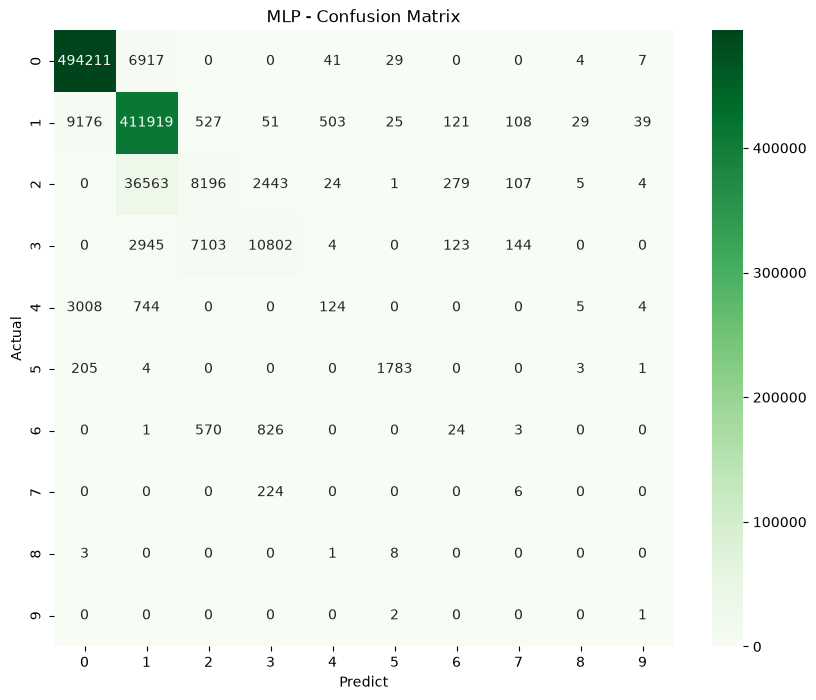

In [8]:
y_pred_best = best_mlp.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy with best MLP classifier: {(acc_best*100):.2f}%")

print("Classification Report:\n", classification_report(y_test, y_pred_best))
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('MLP - Confusion Matrix')
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.show()
